In [18]:
!pip install pandas numpy scikit-learn nltk textblob xgboost tqdm

In [19]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [39]:
!wget https://myleott.com/op_spam_v1.4.zip

--2026-03-06 22:02:06--  https://myleott.com/op_spam_v1.4.zip
Resolving myleott.com (myleott.com)... 104.21.41.81, 172.67.163.64, 2606:4700:3035::ac43:a340, ...
Connecting to myleott.com (myleott.com)|104.21.41.81|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1172634 (1.1M) [application/x-zip-compressed]
Saving to: ‘op_spam_v1.4.zip’

op_spam_v1.4.zip    100%[===================>]   1.12M  --.-KB/s    in 0.01s   

2026-03-06 22:02:07 (96.6 MB/s) - ‘op_spam_v1.4.zip’ saved [1172634/1172634]



In [40]:
!unzip op_spam_v1.4.zip

Archive:  op_spam_v1.4.zip
   creating: op_spam_v1.4/
  inflating: op_spam_v1.4/LICENSE    
   creating: op_spam_v1.4/negative_polarity/
   creating: op_spam_v1.4/negative_polarity/deceptive_from_MTurk/
   creating: op_spam_v1.4/negative_polarity/deceptive_from_MTurk/fold1/
  inflating: op_spam_v1.4/negative_polarity/deceptive_from_MTurk/fold1/d_hilton_1.txt  
  inflating: op_spam_v1.4/negative_polarity/deceptive_from_MTurk/fold1/d_hilton_10.txt  
  inflating: op_spam_v1.4/negative_polarity/deceptive_from_MTurk/fold1/d_hilton_11.txt  
  inflating: op_spam_v1.4/negative_polarity/deceptive_from_MTurk/fold1/d_hilton_12.txt  
  inflating: op_spam_v1.4/negative_polarity/deceptive_from_MTurk/fold1/d_hilton_13.txt  
  inflating: op_spam_v1.4/negative_polarity/deceptive_from_MTurk/fold1/d_hilton_14.txt  
  inflating: op_spam_v1.4/negative_polarity/deceptive_from_MTurk/fold1/d_hilton_15.txt  
  inflating: op_spam_v1.4/negative_polarity/deceptive_from_MTurk/fold1/d_hilton_16.txt  
  inflating: o

In [41]:
import os
import pandas as pd

data = []

base_path = "op_spam_v1.4"

for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(".txt"):

            path = os.path.join(root, file)

            with open(path, "r", encoding="utf8") as f:
                review = f.read()

            label = 1 if "deceptive" in root else 0

            data.append({
                "review_text": review,
                "label": label
            })

df = pd.DataFrame(data)

print(df.shape)
df.head()

(1600, 2)


,review_text,label
0,Seriously overpriced The room was clean and co...,0
1,"First let me say, I try not to be too critical...",0
2,I booked this hotel with great expectations. I...,0
3,Booked a room w/ a queen bed for 2 nights for ...,0
4,My family of four went to a convention and sta...,0


In [42]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()
    text = re.sub(r"[^a-zA-Z ]", "", text)

    words = text.split()
    words = [w for w in words if w not in stop_words]

    return " ".join(words)

df["clean_review"] = df["review_text"].apply(clean_text)

In [43]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=10000)

tokenizer.fit_on_texts(df["clean_review"])

X = tokenizer.texts_to_sequences(df["clean_review"])

X = pad_sequences(X, maxlen=200)

y = df["label"]

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense

model = Sequential()

model.add(Embedding(10000, 128, input_length=200))

model.add(Bidirectional(LSTM(64)))

model.add(Dense(1, activation="sigmoid"))

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [46]:
model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.5072 - loss: 0.6932 - val_accuracy: 0.7344 - val_loss: 0.6106
Epoch 2/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8291 - loss: 0.4983 - val_accuracy: 0.8047 - val_loss: 0.4205
Epoch 3/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9446 - loss: 0.1831 - val_accuracy: 0.8438 - val_loss: 0.4391
Epoch 4/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9785 - loss: 0.0846 - val_accuracy: 0.8516 - val_loss: 0.4503
Epoch 5/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9959 - loss: 0.0263 - val_accuracy: 0.8516 - val_loss: 0.4756


In [47]:
loss, acc = model.evaluate(X_test, y_test)

print("Accuracy:", acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7987 - loss: 0.5425
Accuracy: 0.8125


In [ ]:
#Adding Attention Layer

In [48]:
!pip install tensorflow-addons

ERROR: Could not find a version that satisfies the requirement tensorflow-addons (from versions: none)
ERROR: No matching distribution found for tensorflow-addons


In [49]:
import tensorflow as tf
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Layer, Input
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K

class Attention(Layer):
    def __init__(self):
        super(Attention, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(
            shape=(input_shape[-1], 1),
            initializer="normal",
            trainable=True
        )
        self.b = self.add_weight(
            shape=(input_shape[1], 1),
            initializer="zeros",
            trainable=True
        )

    def call(self, x):
        e = K.tanh(K.dot(x, self.W) + self.b)
        a = K.softmax(e, axis=1)
        output = x * a
        return K.sum(output, axis=1)

input_layer = Input(shape=(200,))

embedding = Embedding(10000, 128)(input_layer)

bilstm = Bidirectional(LSTM(64, return_sequences=True))(embedding)

attention = Attention()(bilstm)

dense = Dense(32, activation="relu")(attention)

output = Dense(1, activation="sigmoid")(dense)

model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 200, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (Attention)           │ (None, 128)            │           328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,383,305 (5.28 MB)

 Trainable params: 1,383,305 (5.28 MB)

 Non-trainable params: 0 (0.00 B)

In [50]:
model.fit(
    X_train,
    y_train,
    epochs=6,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/6
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.4922 - loss: 0.6934 - val_accuracy: 0.4609 - val_loss: 0.6954
Epoch 2/6
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5436 - loss: 0.6829 - val_accuracy: 0.7656 - val_loss: 0.5293
Epoch 3/6
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8518 - loss: 0.3753 - val_accuracy: 0.8594 - val_loss: 0.4017
Epoch 4/6
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9507 - loss: 0.1568 - val_accuracy: 0.8828 - val_loss: 0.3310
Epoch 5/6
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9787 - loss: 0.0630 - val_accuracy: 0.8594 - val_loss: 0.3491
Epoch 6/6
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9941 - loss: 0.0304 - val_accuracy: 0.8750 - val_loss: 0.4490


In [51]:
loss, acc = model.evaluate(X_test, y_test)

print("Accuracy:", acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8775 - loss: 0.4150
Accuracy: 0.8656250238418579


In [ ]:
# using Glove embeddings for sementic Overview

In [52]:
!wget http://nlp.stanford.edu/data/glove.6B.zip

--2026-03-06 22:09:41--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-03-06 22:09:41--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-03-06 22:09:42--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [53]:
!unzip glove.6B.zip

Archive:  glove.6B.zip
  inflating: glove.6B.50d.txt        
  inflating: glove.6B.100d.txt       
  inflating: glove.6B.200d.txt       
  inflating: glove.6B.300d.txt       


In [54]:
import numpy as np

embedding_index = {}

with open("glove.6B.100d.txt", encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embedding_index[word] = vector

print("Loaded word vectors:", len(embedding_index))

Loaded word vectors: 400000


In [55]:
embedding_dim = 100

word_index = tokenizer.word_index

embedding_matrix = np.zeros((10000, embedding_dim))

for word, i in word_index.items():

    if i >= 10000:
        continue

    embedding_vector = embedding_index.get(word)

    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

In [60]:
from tensorflow.keras.layers import Embedding

embedding_layer = Embedding(
    input_dim=10000,
    output_dim=100,
    weights=[embedding_matrix],
    input_length=200,
    trainable=True
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [61]:
input_layer = Input(shape=(200,))

embedding = embedding_layer(input_layer)

bilstm = Bidirectional(LSTM(64, return_sequences=True))(embedding)

attention = Attention()(bilstm)

dense = Dense(32, activation="relu")(attention)

output = Dense(1, activation="sigmoid")(dense)

model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (None, 200, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 200, 128)       │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_2 (Attention)         │ (None, 128)            │           328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,088,969 (4.15 MB)

 Trainable params: 1,088,969 (4.15 MB)

 Non-trainable params: 0 (0.00 B)

In [64]:
model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9872 - loss: 0.0502 - val_accuracy: 0.8828 - val_loss: 0.3831
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9847 - loss: 0.0541 - val_accuracy: 0.8750 - val_loss: 0.3714
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9958 - loss: 0.0263 - val_accuracy: 0.8906 - val_loss: 0.4414
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9991 - loss: 0.0130 - val_accuracy: 0.8750 - val_loss: 0.6314
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9922 - loss: 0.0229 - val_accuracy: 0.8359 - val_loss: 0.5758
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9988 - loss: 0.0092 - val_accuracy: 0.8672 - val_loss: 0.4179
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9979 - loss: 0.0144 - val_accuracy: 0.8750 - val_loss: 0.4960
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9959 - loss: 0.0185 - val_accuracy: 0.8516 - v

In [65]:
loss, acc = model.evaluate(X_test, y_test)

print("Accuracy:", acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8373 - loss: 0.8908
Accuracy: 0.840624988079071


In [ ]:
# improved Attention Model

In [66]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

vocab_size = 20000
max_len = 300

tokenizer = Tokenizer(num_words=vocab_size)

tokenizer.fit_on_texts(df["clean_review"])

X = tokenizer.texts_to_sequences(df["clean_review"])

X = pad_sequences(X, maxlen=max_len)

y = df["label"]

In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [68]:
import numpy as np

embedding_index = {}

with open("glove.6B.100d.txt", encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embedding_index[word] = vector

print("Loaded vectors:", len(embedding_index))

Loaded vectors: 400000


In [69]:
embedding_dim = 100

word_index = tokenizer.word_index

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in word_index.items():

    if i >= vocab_size:
        continue

    embedding_vector = embedding_index.get(word)

    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

In [70]:
import tensorflow.keras.backend as K
from tensorflow.keras.layers import Layer

class Attention(Layer):

    def build(self, input_shape):
        self.W = self.add_weight(
            shape=(input_shape[-1], 1),
            initializer="normal"
        )

        self.b = self.add_weight(
            shape=(input_shape[1], 1),
            initializer="zeros"
        )

    def call(self, x):
        e = K.tanh(K.dot(x, self.W) + self.b)
        a = K.softmax(e, axis=1)
        output = x * a
        return K.sum(output, axis=1)

In [71]:
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, Input
from tensorflow.keras.models import Model

embedding_layer = Embedding(
    vocab_size,
    embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=True
)

input_layer = Input(shape=(max_len,))

embedding = embedding_layer(input_layer)

bilstm = Bidirectional(
    LSTM(
        64,
        return_sequences=True,
        dropout=0.3,
        recurrent_dropout=0.3
    )
)(embedding)

attention = Attention()(bilstm)

dense = Dense(32, activation="relu")(attention)

drop = Dropout(0.5)(dense)

output = Dense(1, activation="sigmoid")(drop)

model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_4 (Embedding)         │ (None, 300, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 300, 128)       │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_3 (Attention)         │ (None, 128)            │           428 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,089,069 (7.97 MB)

 Trainable params: 2,089,069 (7.97 MB)

 Non-trainable params: 0 (0.00 B)

In [72]:
model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.5024 - loss: 0.6952 - val_accuracy: 0.5703 - val_loss: 0.6899
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.5110 - loss: 0.6920 - val_accuracy: 0.5000 - val_loss: 0.6896
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.5196 - loss: 0.6895 - val_accuracy: 0.6719 - val_loss: 0.6538
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.6659 - loss: 0.6423 - val_accuracy: 0.8281 - val_loss: 0.4668
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.7747 - loss: 0.5015 - val_accuracy: 0.8672 - val_loss: 0.3737
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.8314 - loss: 0.3835 - val_accuracy: 0.8750 - val_loss: 0.3352
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9087 - loss: 0.2399 - val_accuracy: 0.8828 - val_loss: 0.3163
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.9307 - loss: 0.2113 - val_accuracy: 0.8750 - val_loss:

In [73]:
loss, acc = model.evaluate(X_test, y_test)

print("Final Accuracy:", acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 458ms/step - accuracy: 0.8488 - loss: 0.4907
Final Accuracy: 0.84375


In [ ]:
# moving to BERT for better accuracy

In [76]:
!pip install transformers torch datasets

In [77]:
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments
import torch
import pandas as pd

In [78]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

texts = df["clean_review"].tolist()
labels = df["label"].tolist()

encodings = tokenizer(
    texts,
    truncation=True,
    padding=True,
    max_length=256
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [79]:
class ReviewDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}

        item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):
        return len(self.labels)

In [80]:
class ReviewDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}

        item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):
        return len(self.labels)

In [81]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42
)

train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=256
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=256
)

train_dataset = ReviewDataset(train_encodings, train_labels)
test_dataset = ReviewDataset(test_encodings, test_labels)

In [82]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [83]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir="./logs",
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [86]:
from sklearn.metrics import accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

In [88]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [89]:
trainer.evaluate()

{'eval_loss': 1.121754765510559,
 'eval_model_preparation_time': 0.0051,
 'eval_accuracy': 0.8125,
 'eval_runtime': 5.0459,
 'eval_samples_per_second': 63.418,
 'eval_steps_per_second': 7.927}

In [ ]:
# adding sentiment inconsistency features

In [90]:
from textblob import TextBlob

def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

df["sentiment"] = df["clean_review"].apply(get_sentiment)

In [91]:
import numpy as np

sentiment_feature = np.array(df["sentiment"]).reshape(-1,1)

In [92]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, X_train_sent, X_test_sent, y_train, y_test = train_test_split(
    X,
    sentiment_feature,
    y,
    test_size=0.2,
    random_state=42
)

In [93]:
from tensorflow.keras.layers import Concatenate
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

In [94]:
text_input = Input(shape=(max_len,))

embedding = embedding_layer(text_input)

bilstm = Bidirectional(
    LSTM(64, return_sequences=True, dropout=0.3)
)(embedding)

attention = Attention()(bilstm)

In [95]:
sentiment_input = Input(shape=(1,))

In [96]:
merged = Concatenate()([attention, sentiment_input])

dense = Dense(32, activation="relu")(merged)

output = Dense(1, activation="sigmoid")(dense)

In [97]:
model = Model(
    inputs=[text_input, sentiment_input],
    outputs=output
)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 300, 100)  │  2,000,000 │ input_layer_5[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_5     │ (None, 300, 128)  │     84,480 │ embedding_4[1][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_4         │ (None, 128)       │        428 │ bidirectional_5[… │
│ (Attention)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_6       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 129)       │          0 │ attention_4[0][0… │
│ (Concatenate)       │                   │            │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 32)        │      4,160 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 1)         │         33 │ dense_9[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,089,101 (7.97 MB)

 Trainable params: 2,089,101 (7.97 MB)

 Non-trainable params: 0 (0.00 B)

In [98]:
model.fit(
    [X_train_text, X_train_sent],
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.5386 - loss: 0.6864 - val_accuracy: 0.7031 - val_loss: 0.6004
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8361 - loss: 0.4471 - val_accuracy: 0.8594 - val_loss: 0.3261
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9456 - loss: 0.1772 - val_accuracy: 0.8672 - val_loss: 0.3742
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9708 - loss: 0.0979 - val_accuracy: 0.8750 - val_loss: 0.3705
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9783 - loss: 0.0596 - val_accuracy: 0.7969 - val_loss: 0.7566
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9743 - loss: 0.0649 - val_accuracy: 0.8828 - val_loss: 0.3956
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9817 - loss: 0.0526 - val_accuracy: 0.8828 - val_loss: 0.4360
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9891 - loss: 0.0385 - val_accuracy: 0.8906 - v

In [99]:
loss, acc = model.evaluate(
    [X_test_text, X_test_sent],
    y_test
)

print("Hybrid Model Accuracy:", acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8374 - loss: 0.7256
Hybrid Model Accuracy: 0.84375


In [102]:
print(len(y_test))
print(len(pred))

320
10000


In [103]:
pred = model.predict([X_test_text, X_test_sent])

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


In [104]:
pred = (pred > 0.5).astype(int)

In [105]:
print(len(y_test))
print(len(pred))

320
320


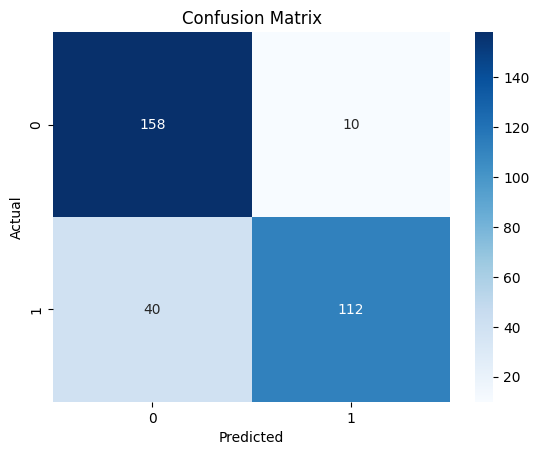

In [106]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [107]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.80      0.94      0.86       168
           1       0.92      0.74      0.82       152

    accuracy                           0.84       320
   macro avg       0.86      0.84      0.84       320
weighted avg       0.86      0.84      0.84       320

